In [1]:
import sys
import os
import math
import random
import hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import concurrent.futures

sys.path.append(str(Path.cwd().parent))
from src.simulation import (
    simulate_sir,
    choose_immunized_random,
    choose_immunized_by_degree,
    choose_immunized_by_eigenvector_centrality,
    choose_immunized_by_adaptive_degree,
    choose_immunized_by_highest,
    choose_immunized_by_neighbor_nomination,
)
from src.data_processing import load_wy_county_graphs

In [2]:
BETA = 0.32
GAMMA = 0.13
STEPS = 200
N_INFECTED = 5
K_PERCENTAGES = list(range(0, 81, 10))
N_TRIALS = 100
BASE_SEED = 20260308

strategy_functions = {
    "Random": choose_immunized_random,
    "Degree": choose_immunized_by_degree,
    "Eigenvector": choose_immunized_by_eigenvector_centrality,
    "Adaptive Degree": choose_immunized_by_adaptive_degree,
    "Polled Self Nomination": choose_immunized_by_highest,
    "Polled Neighbor Nomination": choose_immunized_by_neighbor_nomination,
}

DETERMINISTIC_STRATEGIES = {
    "Degree",
    "Eigenvector",
    "Adaptive Degree",
}

AlbanyWY_fp = Path("../data/WY/56001")
print("Performing experiments on Albany County Wyoming")

Performing experiments on Albany County Wyoming


In [3]:
import concurrent.futures
from src.simulation import evaluate_strategy_mc

county_for_curve = Path("../data/WY/56001")
county_id_curve = county_for_curve.name
_, G_curve = load_wy_county_graphs(county_for_curve)

k_pct_curve = 20
k_count_curve = math.floor(k_pct_curve * G_curve.number_of_nodes() / 100)

tasks = []
tasks.append((
    "baseline", None, G_curve, k_count_curve, county_id_curve,
    N_TRIALS, BETA, GAMMA, STEPS, N_INFECTED, BASE_SEED
))

for strategy_name, strategy_fn in strategy_functions.items():
    tasks.append((
        strategy_name, strategy_fn, G_curve, k_count_curve, county_id_curve,
        N_TRIALS, BETA, GAMMA, STEPS, N_INFECTED, BASE_SEED
    ))

out_by_strategy_curve_mean = {}

print(f"Starting parallel execution for {len(tasks)} tasks...")

with concurrent.futures.ProcessPoolExecutor(max_workers=len(tasks)) as executor:
    results = executor.map(evaluate_strategy_mc, tasks)

    for strategy_name, mean_curve, mean_total in results:
        out_by_strategy_curve_mean[strategy_name] = mean_curve
        print(f"Finished: {strategy_name}")

Starting parallel execution for 7 tasks...
Finished: baseline
Finished: Random
Finished: Degree
Finished: Eigenvector
Finished: Adaptive Degree
Finished: Polled Self Nomination
Finished: Polled Neighbor Nomination


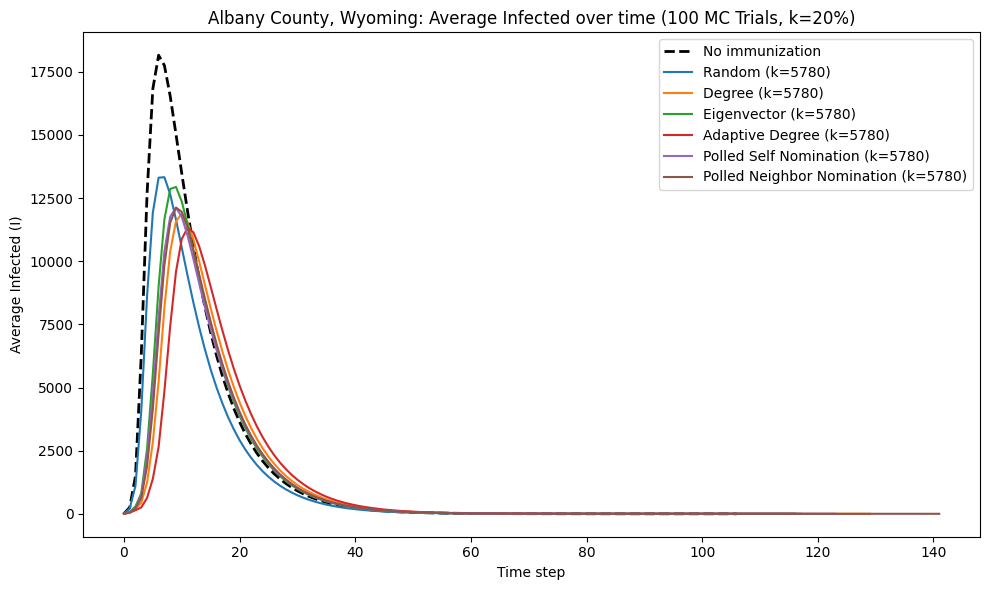

In [4]:
plt.figure(figsize=(10, 6))

if "baseline" in out_by_strategy_curve_mean:
    plt.plot(
        out_by_strategy_curve_mean.pop("baseline"),
        label="No immunization",
        linewidth=2,
        color='black',
        linestyle='--'
    )

for strategy_name, mean_curve in out_by_strategy_curve_mean.items():
    plt.plot(mean_curve, label=f"{strategy_name} (k={k_count_curve})")

plt.title(f"Albany County, Wyoming: Average Infected over time ({N_TRIALS} MC Trials, k={k_pct_curve}%)")
plt.xlabel("Time step")
plt.ylabel("Average Infected (I)")
plt.legend()
plt.tight_layout()
plt.show()

Starting parallel batch runs for 9 different budget sizes...
Finished K=0%
Finished K=10%
Finished K=20%
Finished K=30%
Finished K=40%
Finished K=50%
Finished K=60%
Finished K=70%
Finished K=80%

--- EXPECTED VALUES BY BUDGET AND STRATEGY ---
county  k_pct                   strategy  peak_mean  total_mean
 56001      0                   baseline   18134.53    27867.67
 56001      0                     Random   18102.87    27868.30
 56001      0                     Degree   18109.60    27869.17
 56001      0                Eigenvector   18106.19    27867.43
 56001      0            Adaptive Degree   18191.05    27862.14
 56001      0     Polled Self Nomination   18220.65    27858.67
 56001      0 Polled Neighbor Nomination   18227.69    27871.02
 56001     10                   baseline   18188.02    27861.89
 56001     10                     Random   15696.85    24593.34
 56001     10                     Degree   14979.35    24576.44
 56001     10                Eigenvector   15261.62  

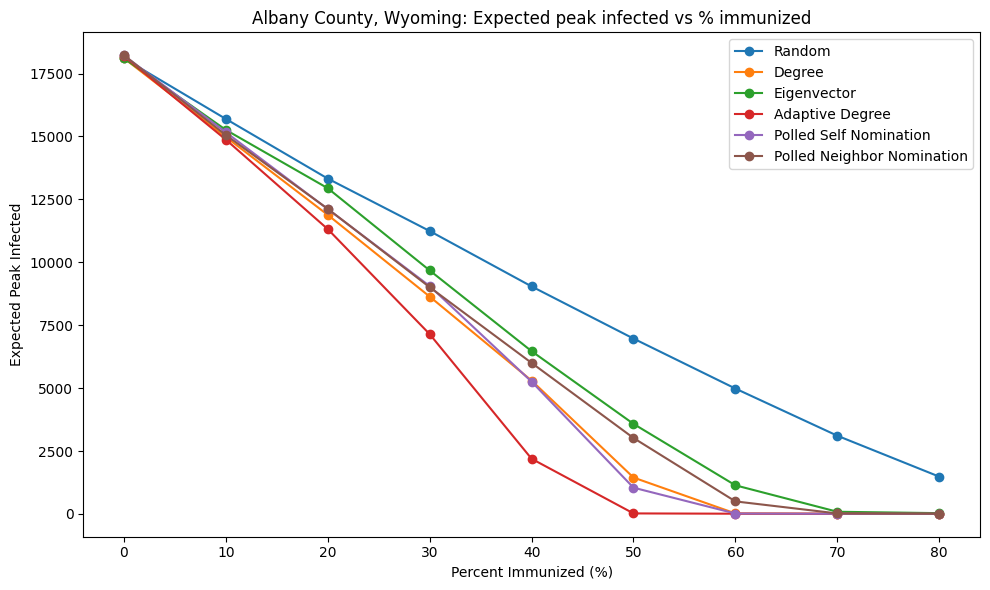

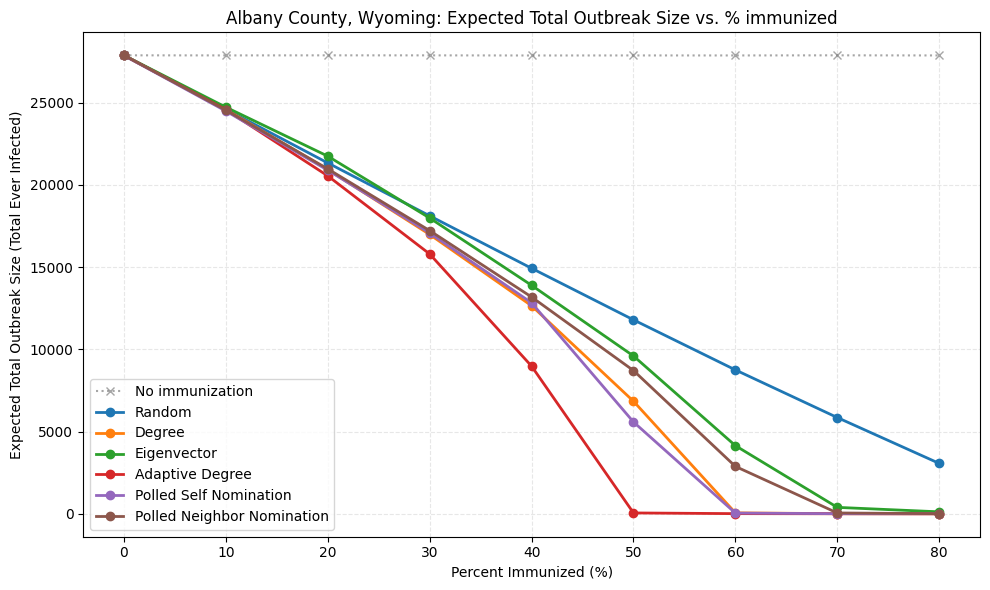

In [5]:
import pandas as pd
import numpy as np
import concurrent.futures

K_PERCENTAGES = list(range(0, 81, 10))
results_list = []

print(f"Starting parallel batch runs for {len(K_PERCENTAGES)} different budget sizes...")

for k_pct in K_PERCENTAGES:
    k_count = math.floor(k_pct * G_curve.number_of_nodes() / 100)

    tasks = [("baseline", None, G_curve, k_count, county_id_curve,
              N_TRIALS, BETA, GAMMA, STEPS, N_INFECTED, BASE_SEED)]
    for strategy_name, strategy_fn in strategy_functions.items():
        tasks.append((strategy_name, strategy_fn, G_curve, k_count, county_id_curve,
                      N_TRIALS, BETA, GAMMA, STEPS, N_INFECTED, BASE_SEED))

    with concurrent.futures.ProcessPoolExecutor(max_workers=len(tasks)) as executor:
        results = executor.map(evaluate_strategy_mc, tasks)

        for strategy_name, mean_curve, mean_total in results:
            peak_mean = np.max(mean_curve)

            results_list.append({
                "county": county_id_curve,
                "k_pct": k_pct,
                "strategy": strategy_name,
                "peak_mean": peak_mean,
                "total_mean": mean_total
            })
    print(f"Finished K={k_pct}%")

results_df = pd.DataFrame(results_list)
results_values_df = results_df.sort_values(["k_pct", "peak_mean"])
print("\n--- EXPECTED VALUES BY BUDGET AND STRATEGY ---")
print(results_df.to_string(index=False))

results_df.to_csv(f"{county_id_curve}_expected_values.csv", index=False)

summary = (
    results_df.groupby(["county", "k_pct", "strategy"], as_index=False)
    .agg(peak_mean=("peak_mean", "mean"), total_mean=("total_mean", "mean"))
)

ranking = (
    summary.groupby("strategy", as_index=False)
    .agg(avg_peak=("peak_mean", "mean"), avg_total=("total_mean", "mean"))
    .sort_values("avg_peak")
)
print(ranking)

county_to_plot = county_id_curve
subset = summary[summary["county"] == county_to_plot]

plt.figure(figsize=(10, 6))
for strategy_name in strategy_functions:
    s = subset[subset["strategy"] == strategy_name]
    plt.plot(s["k_pct"], s["peak_mean"], marker="o", label=strategy_name)

plt.title(f"Albany County, Wyoming: Expected peak infected vs % immunized")
plt.xlabel("Percent Immunized (%)")
plt.ylabel("Expected Peak Infected")
plt.legend()
plt.tight_layout()
plt.savefig(f"{county_id_curve}_peak_outbreak_analysis.png", dpi=300)
plt.figure(figsize=(10, 6))

strategies = results_df['strategy'].unique()

if 'baseline' in strategies:
    baseline_data = results_df[results_df['strategy'] == 'baseline'].sort_values('k_pct')
    plt.plot(
        baseline_data['k_pct'],
        baseline_data['total_mean'],
        label='No immunization',
        color='gray',
        linestyle=':',
        linewidth=1.5,
        marker='x',
        alpha=0.7
    )

for strategy in strategies:
    if strategy == 'baseline':
        continue

    strat_data = results_df[results_df['strategy'] == strategy].sort_values('k_pct')
    plt.plot(
        strat_data['k_pct'],
        strat_data['total_mean'],
        label=strategy,
        marker='o',
        linewidth=2
    )

plt.title(f"Albany County, Wyoming: Expected Total Outbreak Size vs. % immunized")
plt.xlabel("Percent Immunized (%)")
plt.ylabel("Expected Total Outbreak Size (Total Ever Infected)")
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(f"{county_id_curve}_total_outbreak_analysis.png", dpi=300)
plt.show()

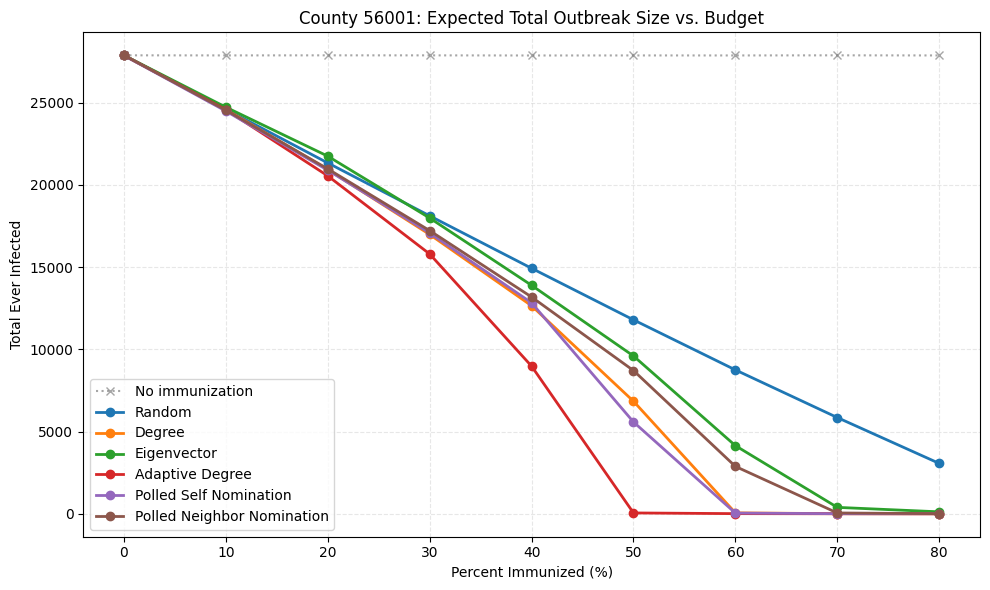

In [6]:
plt.figure(figsize=(10, 6))

strategies = results_df['strategy'].unique()

if 'baseline' in strategies:
    baseline_data = results_df[results_df['strategy'] == 'baseline'].sort_values('k_pct')
    plt.plot(
        baseline_data['k_pct'],
        baseline_data['total_mean'],
        label='No immunization',
        color='gray',
        linestyle=':',
        linewidth=1.5,
        marker='x',
        alpha=0.7
    )

for strategy in strategies:
    if strategy == 'baseline':
        continue

    strat_data = results_df[results_df['strategy'] == strategy].sort_values('k_pct')
    plt.plot(
        strat_data['k_pct'],
        strat_data['total_mean'],
        label=strategy,
        marker='o',
        linewidth=2
    )

plt.title(f"County {56001}: Expected Total Outbreak Size vs. Budget")
plt.xlabel("Percent Immunized (%)")
plt.ylabel("Total Ever Infected")
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()